In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.7 MB/s eta 0:00:00


Đang khởi tạo Hệ thống Lai Nâng cao...

0: 448x640 28 persons, 48 cars, 5 motorcycles, 7 buss, 8 trucks, 1 umbrella, 166.0ms
Speed: 4.3ms preprocess, 166.0ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


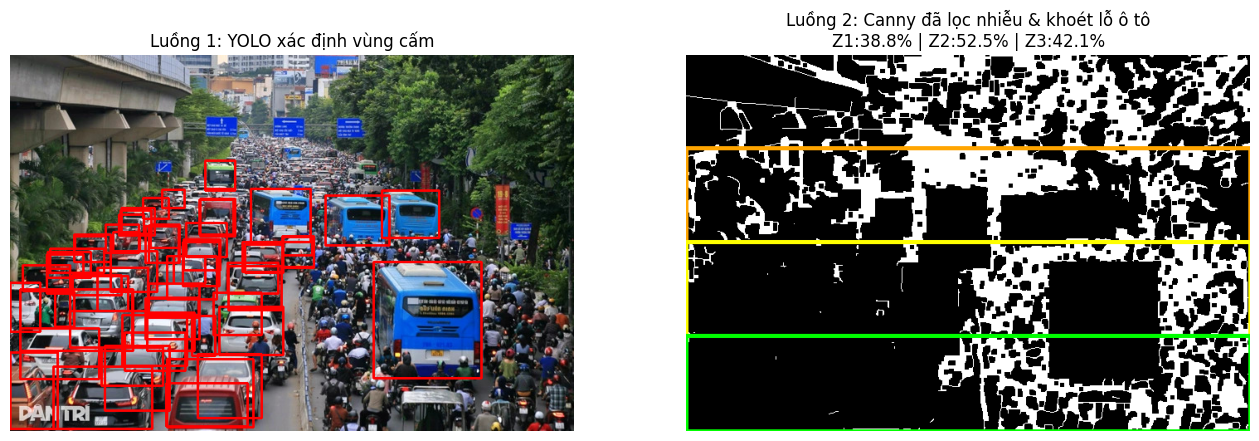


0: 384x640 19 persons, 5 cars, 1 motorcycle, 10 buss, 213.2ms
Speed: 3.0ms preprocess, 213.2ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


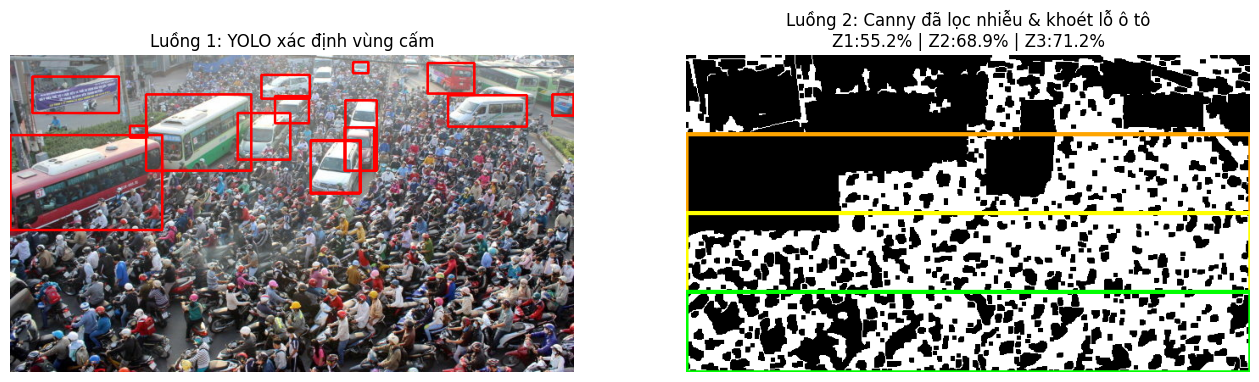

Lỗi: Không tìm thấy ảnh '/content/2.webp'

0: 352x640 26 persons, 47 cars, 4 motorcycles, 4 buss, 2 trucks, 222.9ms
Speed: 3.4ms preprocess, 222.9ms inference, 1.9ms postprocess per image at shape (1, 3, 352, 640)


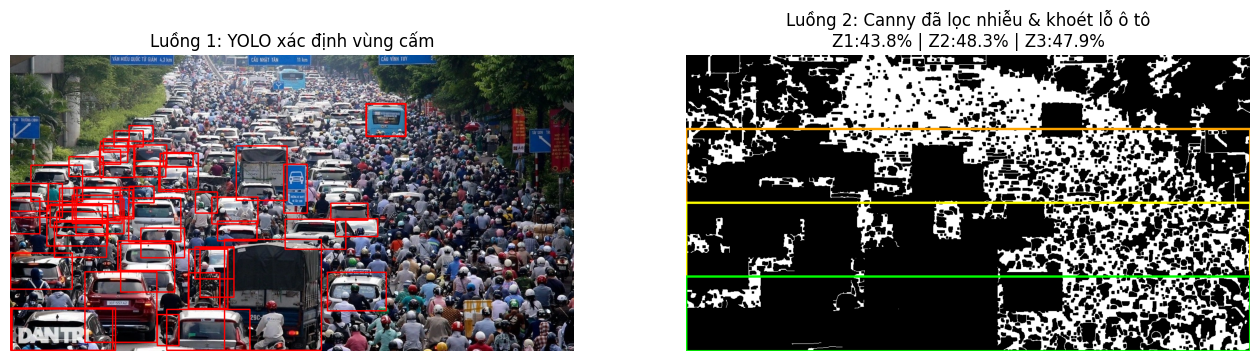


0: 480x640 26 persons, 1 bicycle, 28 cars, 3 motorcycles, 6 buss, 3 trucks, 249.0ms
Speed: 5.5ms preprocess, 249.0ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


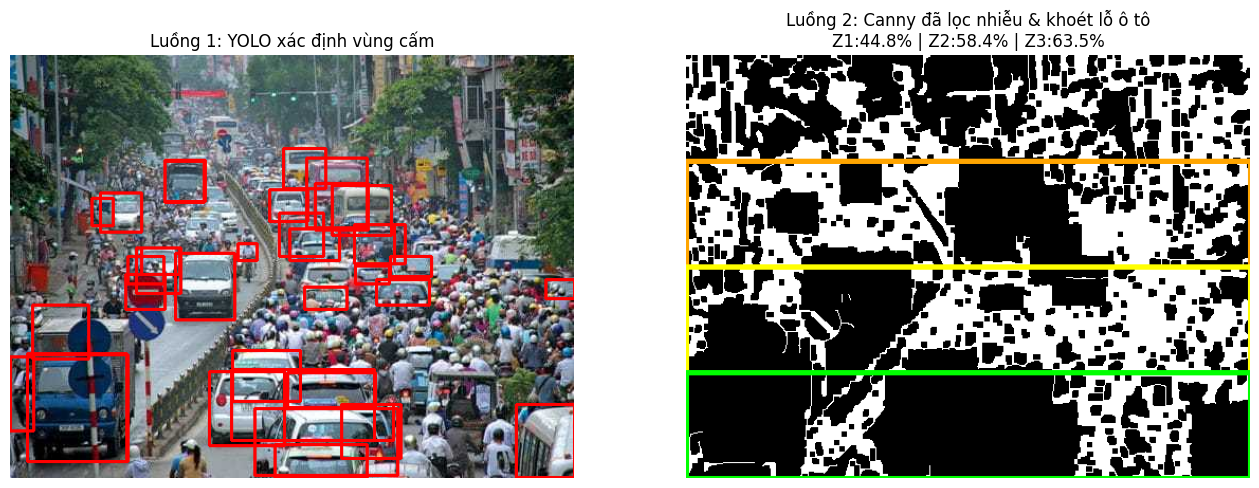


0: 384x640 7 persons, 6 cars, 7 buss, 193.6ms
Speed: 3.0ms preprocess, 193.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


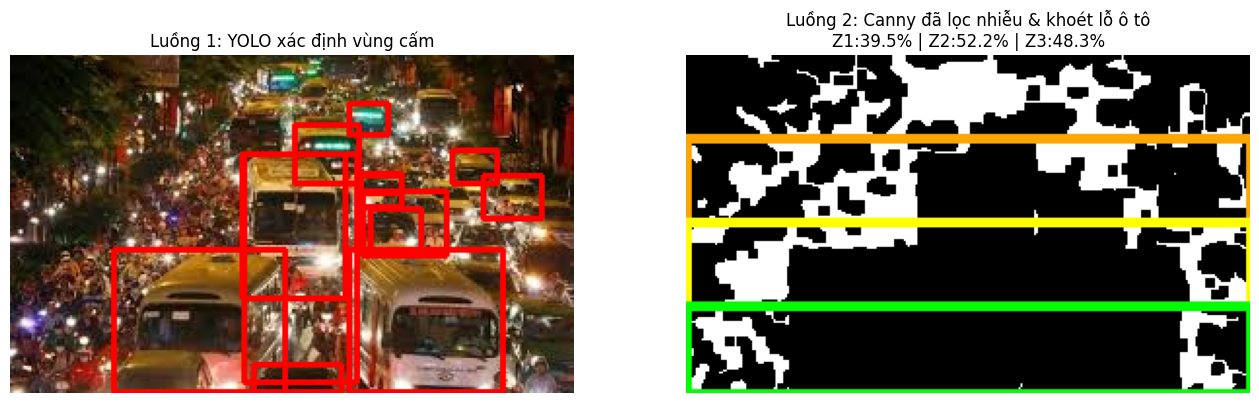

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

class AdvancedStaticHybridAnalyzer:
    def __init__(self, yolo_model='yolov8n.pt'):
        print("Đang khởi tạo Hệ thống Lai Nâng cao...")
        self.model = YOLO(yolo_model)
        self.large_vehicle_classes = {2: 'car', 5: 'bus', 7: 'truck'}

    def analyze_image(self, image_path):
        if not os.path.exists(image_path):
            print(f"Lỗi: Không tìm thấy ảnh '{image_path}'")
            return

        image = cv2.imread(image_path)
        img_h, img_w = image.shape[:2]

        # --- LUỒNG 1: YOLO Nhận diện xe lớn ---
        yolo_result_img = image.copy()
        results = self.model(image, conf=0.05, iou=0.6)

        # Lưu lại tọa độ các xe lớn để "khoét lỗ" ở Luồng 2
        large_boxes = []

        for box in results[0].boxes:
            cls_id = int(box.cls[0])
            if cls_id in self.large_vehicle_classes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                large_boxes.append((x1, y1, x2, y2))
                cv2.rectangle(yolo_result_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

        # --- LUỒNG 2: Classic CV Nâng cao (Có kết nối với Luồng 1) ---
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # 1. Trả lại độ mờ vừa phải để không làm mất viền xe
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)

        # 2. Ngưỡng Canny nhạy hơn để bắt được đám đông
        edges = cv2.Canny(blurred, 50, 150)

        # 3. KỸ THUẬT QUAN TRỌNG: "Khoét lỗ" mặt nạ bằng tọa độ YOLO
        # Tô màu ĐEN (0) vào vị trí của ô tô/xe buýt để không đếm lặp
        for (x1, y1, x2, y2) in large_boxes:
            cv2.rectangle(edges, (x1, y1), (x2, y2), 0, -1) # -1 nghĩa là tô kín đặc

        # 4. Trám các nét đứt
        kernel = np.ones((5,5), np.uint8)
        closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
        edge_vis_img = cv2.cvtColor(closed_edges, cv2.COLOR_GRAY2BGR)

        # --- CHIA 3 VÙNG ROI ĐỂ TÍNH MẬT ĐỘ ---
        y_start = int(img_h * 0.25)
        zone_h = (img_h - y_start) // 3
        zones = {
            'Zone_3 (Xa)': (y_start, y_start + zone_h, (0, 165, 255)),
            'Zone_2 (Cho)': (y_start + zone_h, y_start + 2*zone_h, (0, 255, 255)),
            'Zone_1 (Gan)': (y_start + 2*zone_h, img_h, (0, 255, 0))
        }

        zone_densities = {}
        for zone_name, (y1, y2, color) in zones.items():
            # Bước tính diện tích cũng phải khôn ngoan hơn:
            # Phải TRỪ ĐI diện tích của xe lớn nằm trong vùng này
            zone_mask = np.ones((y2 - y1, img_w), dtype=np.uint8) * 255
            for (x1, bx_y1, x2, bx_y2) in large_boxes:
                # Tìm phần giao nhau giữa bounding box và Zone hiện tại
                inter_y1 = max(y1, bx_y1) - y1
                inter_y2 = min(y2, bx_y2) - y1
                if inter_y1 < inter_y2:
                    cv2.rectangle(zone_mask, (x1, inter_y1), (x2, inter_y2), 0, -1)

            # Diện tích mặt đường THỰC TẾ (đã trừ ô tô)
            actual_road_area = cv2.countNonZero(zone_mask)

            # Đếm pixel trắng của xe máy
            zone_edges = closed_edges[y1:y2, 0:img_w]
            white_pixels = cv2.countNonZero(zone_edges)

            # Tính mật độ an toàn tránh chia cho 0
            density = (white_pixels / actual_road_area * 100) if actual_road_area > 0 else 0
            zone_densities[zone_name] = density

            cv2.rectangle(edge_vis_img, (0, y1), (img_w, y2), color, 3)

        self._visualize_results(yolo_result_img, edge_vis_img, zone_densities)

    def _visualize_results(self, yolo_img, edge_img, densities):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        ax1.imshow(cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB))
        ax1.set_title('Luồng 1: YOLO xác định vùng cấm')
        ax1.axis('off')

        ax2.imshow(cv2.cvtColor(edge_img, cv2.COLOR_BGR2RGB))
        ax2.set_title(f"Luồng 2: Canny đã lọc nhiễu & khoét lỗ ô tô\nZ1:{densities['Zone_1 (Gan)']:.1f}% | Z2:{densities['Zone_2 (Cho)']:.1f}% | Z3:{densities['Zone_3 (Xa)']:.1f}%")
        ax2.axis('off')
        plt.show()

if __name__ == "__main__":
    analyzer = AdvancedStaticHybridAnalyzer('yolov8n.pt')
    analyzer.analyze_image('/content/traffic_2.jpg')
    analyzer.analyze_image('/content/1.jpg')
    analyzer.analyze_image('/content/2.webp')
    analyzer.analyze_image('/content/3.webp')
    analyzer.analyze_image('/content/4.jpg')
    analyzer.analyze_image('/content/5.jpg')